# Customer Insight - 100.000 rows

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
FILE_PATH = "./data/customers-100000.csv"
df = pd.read_csv(FILE_PATH)
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,Sanchez-Fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/
1,2,b687FfC4F1600eC,Marie,Malone,Mckay PLC,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,Marks and Sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"Kirby, Vaughn and Sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,Lester-Manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/


# Data Quality Check

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Index              100000 non-null  int64 
 1   Customer Id        100000 non-null  object
 2   First Name         100000 non-null  object
 3   Last Name          100000 non-null  object
 4   Company            100000 non-null  object
 5   City               100000 non-null  object
 6   Country            100000 non-null  object
 7   Phone 1            100000 non-null  object
 8   Phone 2            100000 non-null  object
 9   Email              100000 non-null  object
 10  Subscription Date  100000 non-null  object
 11  Website            100000 non-null  object
dtypes: int64(1), object(11)
memory usage: 9.2+ MB


In [4]:
duplicates = df.duplicated(subset=['Customer Id']).sum()
print(f"Found {duplicates} duplicate Customer IDs.")
if duplicates > 0:
    df = df.drop_duplicates(subset=['Customer Id'])
    print(f"Dropped duplicates. New row count: {len(df)}")

Found 0 duplicate Customer IDs.


In [5]:
print("\nMissing values per column:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Missing values per column:
Series([], dtype: int64)


In [6]:
def clean_phone_format(phone_str):
    phone_str = str(phone_str).lower()

    cleaned = re.sub(r'[^0-9x+]', '', phone_str)
    cleaned = cleaned.replace('x', ' ext ')
    
    return cleaned

df['Clean_Phone_1'] = df['Phone 1'].apply(clean_phone_format)
df['Clean_Phone_2'] = df['Phone 2'].apply(clean_phone_format)
df[['Phone 1', 'Clean_Phone_1', 'Phone 2', 'Clean_Phone_2']].head(10)

,Phone 1,Clean_Phone_1,Phone 2,Clean_Phone_2
0,274.188.8773x41185,2741888773 ext 41185,001-215-760-4642x969,0012157604642 ext 969
1,283-236-9529,2832369529,(189)129-8356x63741,1891298356 ext 63741
2,8252703789,8252703789,459-916-7241x0909,4599167241 ext 0909
3,425.475.3586,4254753586,(392)819-9063,3928199063
4,+1-223-666-5313x4530,+12236665313 ext 4530,252-488-3850x692,2524883850 ext 692
5,+1-165-340-7100x44099,+11653407100 ext 44099,(847)867-2795x043,8478672795 ext 043
6,426.446.3838,4264463838,437.476.4705,4374764705
7,101-419-0208x043,1014190208 ext 043,931.542.3115x98926,9315423115 ext 98926
8,+1-740-392-0511,+17403920511,+1-218-891-5403x7270,+12188915403 ext 7270
9,0389689232,0389689232,344-952-1181x6911,3449521181 ext 6911


In [7]:
def clean_email(email_str):
    cleaned = str(email_str).strip().lower()
    return cleaned

def is_valid_email(email_str):
    email_regex = r'^[a-z0-9_.+-]+@[a-z0-9-]+\.[a-z0-9-.]+$'
    return bool(re.match(email_regex, email_str))


print("Cleaning and validating emails...")
df['Clean_Email'] = df['Email'].apply(clean_email)
df['Email_Is_Valid'] = df['Clean_Email'].apply(is_valid_email)

invalid_emails = len(df[df['Email_Is_Valid'] == False])
print(f"Found {invalid_emails} invalid or missing emails out of {len(df)}.")

df[['Email', 'Clean_Email', 'Email_Is_Valid']].head(10)

Cleaning and validating emails...
Found 0 invalid or missing emails out of 100000.


,Email,Clean_Email,Email_Is_Valid
0,gabriellehartman@benjamin.com,gabriellehartman@benjamin.com,True
1,kstafford@sexton.com,kstafford@sexton.com,True
2,jeanettecross@brown.com,jeanettecross@brown.com,True
3,thomassierra@barrett.com,thomassierra@barrett.com,True
4,rubenwatkins@jacobs-wallace.info,rubenwatkins@jacobs-wallace.info,True
5,gmurillo@perez.com,gmurillo@perez.com,True
6,melissabenitez@le.info,melissabenitez@le.info,True
7,brent60@lopez.com,brent60@lopez.com,True
8,toddharris@lowery-rosario.biz,toddharris@lowery-rosario.biz,True
9,carolbanks@vang-stafford.com,carolbanks@vang-stafford.com,True


# Data Transformation

In [8]:
# Convert 'Subscription Date' from string to datetime
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Index              100000 non-null  int64         
 1   Customer Id        100000 non-null  object        
 2   First Name         100000 non-null  object        
 3   Last Name          100000 non-null  object        
 4   Company            100000 non-null  object        
 5   City               100000 non-null  object        
 6   Country            100000 non-null  object        
 7   Phone 1            100000 non-null  object        
 8   Phone 2            100000 non-null  object        
 9   Email              100000 non-null  object        
 10  Subscription Date  100000 non-null  datetime64[ns]
 11  Website            100000 non-null  object        
 12  Clean_Phone_1      100000 non-null  object        
 13  Clean_Phone_2      100000 non-null  object   

# Insights

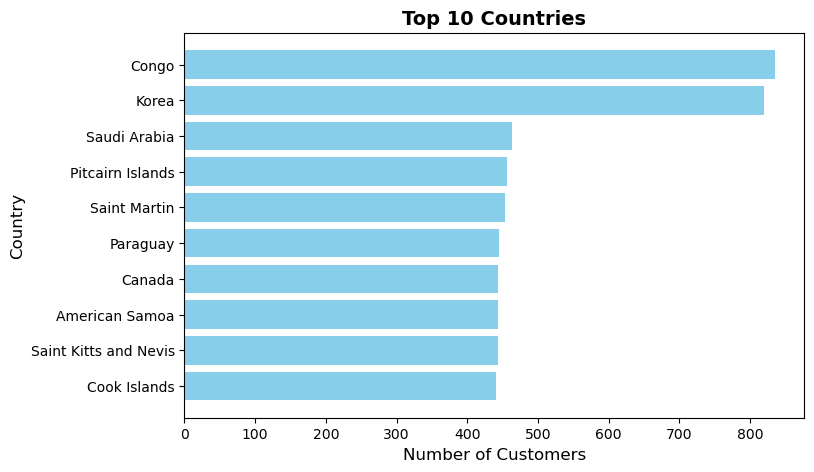

Congo                    835
Korea                    820
Saudi Arabia             463
Pitcairn Islands         456
Saint Martin             453
Paraguay                 445
Canada                   444
American Samoa           443
Saint Kitts and Nevis    443
Cook Islands             441
Name: Country, dtype: int64


In [9]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_countries.index, top_countries.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.show()
print(top_countries)

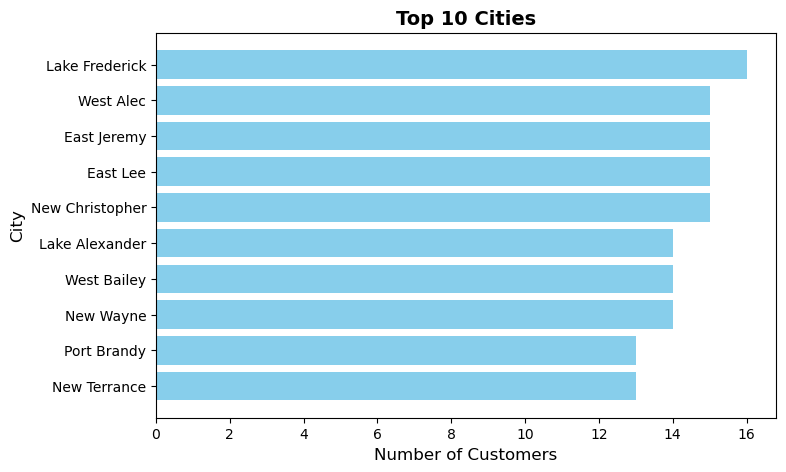

Lake Frederick     16
West Alec          15
East Jeremy        15
East Lee           15
New Christopher    15
Lake Alexander     14
West Bailey        14
New Wayne          14
Port Brandy        13
New Terrance       13
Name: City, dtype: int64


In [10]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_cities.index, top_cities.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Cities', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('City', fontsize=12)

plt.show()
print(top_cities)

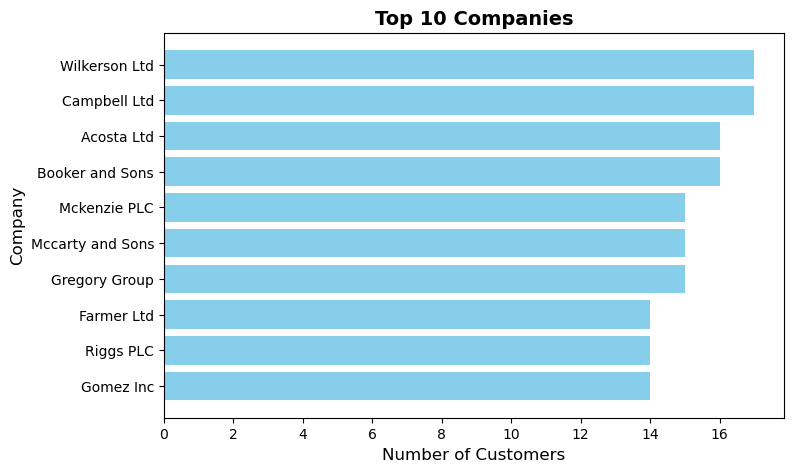

Wilkerson Ltd       17
Campbell Ltd        17
Acosta Ltd          16
Booker and Sons     16
Mckenzie PLC        15
Mccarty and Sons    15
Gregory Group       15
Farmer Ltd          14
Riggs PLC           14
Gomez Inc           14
Name: Company, dtype: int64


In [11]:
top_companies = df['Company'].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_companies.index, top_companies.values, color='skyblue')
plt.gca().invert_yaxis()

plt.title('Top 10 Companies', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Company', fontsize=12)

plt.show()
print(top_companies)

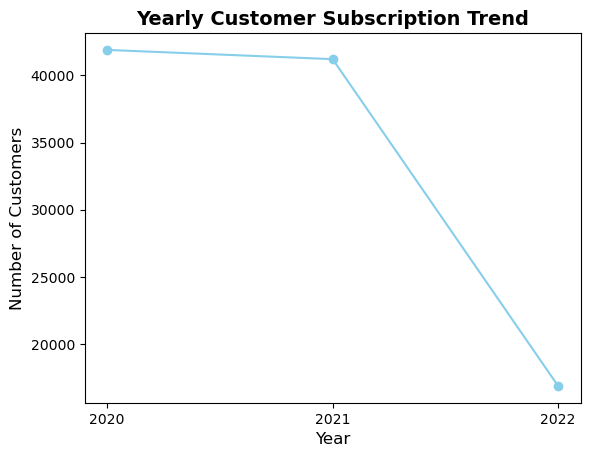

2020    41898
2021    41211
2022    16891
Name: Subscription Date, dtype: int64


In [12]:
yearly_subs = df['Subscription Date'].dt.year.value_counts().sort_index()

plt.plot(yearly_subs.index.astype(str), yearly_subs.values, color='skyblue', marker='o')

plt.title('Yearly Customer Subscription Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()
print(yearly_subs)

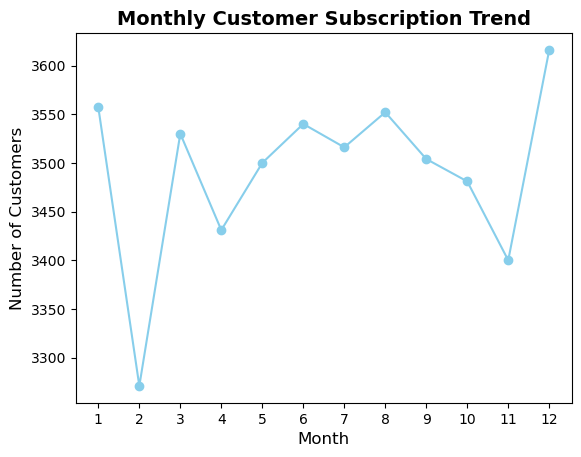

1     3557
2     3271
3     3530
4     3431
5     3500
6     3540
7     3516
8     3552
9     3504
10    3481
11    3400
12    3616
Name: Subscription Date, dtype: int64


In [14]:
chosen_year = int(input("Choose Year: "))

df_filtered = df[df['Subscription Date'].dt.year == chosen_year]

monthly_subs = df_filtered['Subscription Date'].dt.month.value_counts().sort_index()

plt.plot(monthly_subs.index.astype(str), monthly_subs.values, color='skyblue', marker='o')

plt.title('Monthly Customer Subscription Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()
print(monthly_subs)